# 3. Geo-Spatial Analysis: Distribuzione Globale della Fanbase

**Obiettivo:** Analizzare la provenienza geografica degli utenti MAL per identificare i principali mercati e le aree di espansione.

In conformità con la **Lecture 12**, utilizzeremo:
1. **GeoPandas** per l'analisi spaziale statica e il mapping delle geometrie.
2. **Standard ISO-3** per la normalizzazione dei nomi dei paesi, eliminando le ambiguità testuali.
3. **Plotly Express** (Lecture 14) per la creazione di mappe interattive pronte per l'integrazione in una Dashboard.

In [18]:
import pandas as pd
import os

def load_profiles_data():
    possible_paths = ['../cache/profiles.pkl', 'cache/profiles.pkl', 'profiles.pkl']
    for path in possible_paths:
        if os.path.exists(path):
            print(f"Dataset profili caricato correttamente da: {path}")
            return pd.read_pickle(path)
    print("ERRORE: File profiles.pkl non trovato. Esegui prima il Notebook 1.")
    return None

df_profiles = load_profiles_data()

Dataset profili caricato correttamente da: ../cache/profiles.pkl


## 3.1 Normalizzazione ISO-3 e Data Cleaning
Molti utenti inseriscono la propria posizione come testo libero (es. "usa", "italia"). Per proiettare questi dati su una mappa, convertiamo le stringhe nei codici standard **ISO-3**, come raccomandato per evitare i *Deprecation Warning* di Plotly.

In [19]:
possible_cols = ['Location', 'location', 'country', 'city']
col_target = next((c for c in possible_cols if c in df_profiles.columns), None)

if col_target:
    print(f"Utilizzo la colonna: '{col_target}'")

    country_iso_map = {
        'usa': 'USA', 'united states': 'USA', 'us': 'USA', 'america': 'USA',
        'italia': 'ITA', 'italy': 'ITA',
        'germany': 'DEU', 'deutschland': 'DEU', 'germania': 'DEU',
        'france': 'FRA', 'francia': 'FRA',
        'japan': 'JPN', 'nihon': 'JPN', 'giappone': 'JPN',
        'uk': 'GBR', 'united kingdom': 'GBR', 'england': 'GBR',
        'canada': 'CAN', 'brazil': 'BRA', 'brasil': 'BRA',
        'spain': 'ESP', 'espana': 'ESP', 'spagna': 'ESP',
        'russia': 'RUS', 'mexico': 'MEX', 'australia': 'AUS'
    }

    def to_iso3(location):
        if pd.isna(location): return None
        loc_clean = str(location).lower().strip()
        for key, iso in country_iso_map.items():
            if key in loc_clean: return iso
        return None

    df_profiles['iso_code'] = df_profiles[col_target].apply(to_iso3)

    geo_counts = df_profiles['iso_code'].dropna().value_counts().reset_index()
    geo_counts.columns = ['iso_code', 'fan_count']

    print(f"Paesi unici identificati: {len(geo_counts)}")
    print(geo_counts.head())
else:
    print("ERRORE: Nessuna colonna geografica trovata. Colonne disponibili:", df_profiles.columns.tolist())

Utilizzo la colonna: 'Location'
Paesi unici identificati: 10
  iso_code  fan_count
0      JPN      98316
1      USA      74931
2      DEU      26348
3      GBR      19520
4      ESP      12916


## 3.2 Mapping Statico (Lecture 12: GeoPandas)
Utilizziamo il dataset predefinito `naturalearth_lowres` per unire le geometrie del mondo (Poligoni) con i nostri dati di densità. Questo passaggio è fondamentale per gestire i sistemi di riferimento spaziale (CRS).

Geometrie mondiali caricate correttamente.


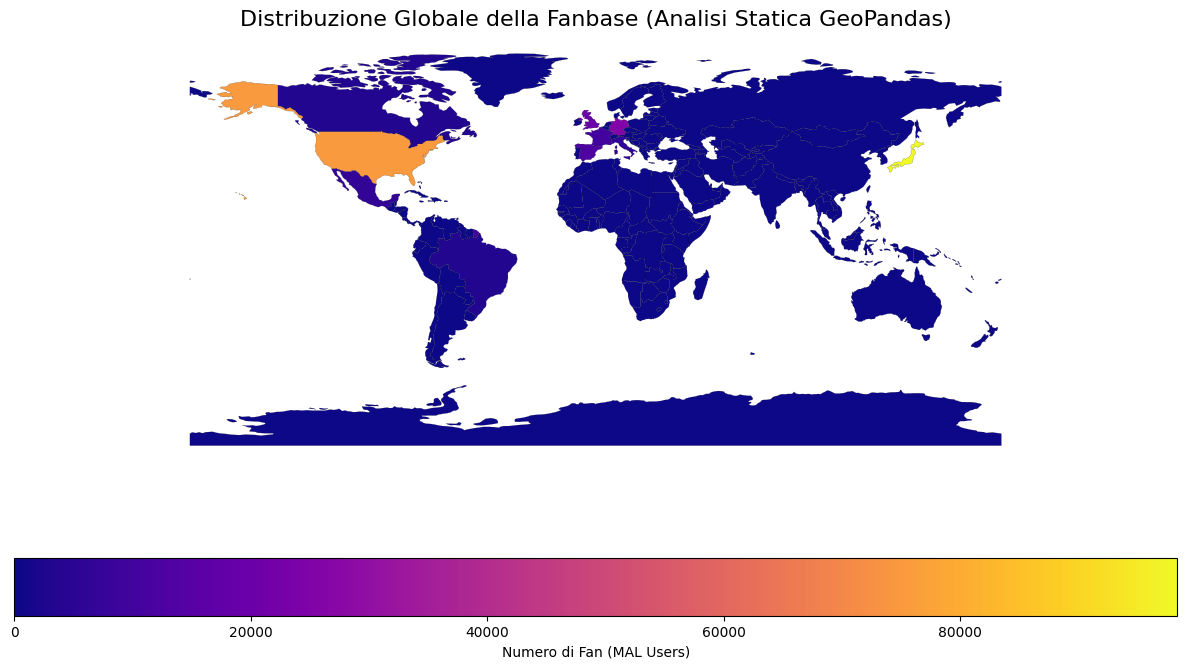

In [20]:
import geopandas as gpd
import matplotlib.pyplot as plt

world_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"

try:
    world = gpd.read_file(world_url)
    print("Geometrie mondiali caricate correttamente.")

    iso_col = 'ADM0_A3' if 'ADM0_A3' in world.columns else 'ISO_A3'

    world_final = world.merge(geo_counts, left_on=iso_col, right_on='iso_code', how='left')

    world_final['fan_count'] = world_final['fan_count'].fillna(0)

    fig, ax = plt.subplots(1, 1, figsize=(15, 8))
    world_final.plot(column='fan_count',
                     ax=ax,
                     legend=True,
                     cmap='plasma',
                     edgecolor='black',
                     linewidth=0.1,
                     legend_kwds={'label': "Numero di Fan (MAL Users)", 'orientation': "horizontal"})

    ax.set_title("Distribuzione Globale della Fanbase (Analisi Statica GeoPandas)", fontsize=16)
    ax.axis('off')
    plt.show()

except Exception as e:
    print(f"Errore durante l'analisi spaziale: {e}")

## 3.3 Verso la Dashboard (Lecture 14: Plotly & Dash)
Per integrare questa analisi in un'applicazione web (Flask/Dash), generiamo una versione interattiva che permette lo zoom e l'ispezione puntuale dei dati tramite hover.

In [21]:
import plotly.express as px

fig_inter = px.choropleth(geo_counts,
                    locations="iso_code",
                    color="fan_count",
                    hover_name="iso_code",
                    locationmode="ISO-3",
                    color_continuous_scale=px.colors.sequential.Plasma,
                    title="Mappa Interattiva della Fanbase Globale (Zoom & Hover)")

fig_inter.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='equirectangular',
        landcolor="lightgrey",
        lakecolor="white"
    ),
    margin={"r":0,"t":50,"l":0,"b":0},
    coloraxis_colorbar=dict(title="Fan Count")
)

fig_inter.show()